# Introduction

In this project, I used the Community Center Daily Attendance dataset. It provides daily attendance counts for different community facilities in Pittsburgh. After analyzing the data, we can know the conditions of each neighborhood. The neighborhoods with more daily total attendance are more active. More active means more chances for people. The dataset I used just provides the daily attendance of each community center. Community center is different from neighborhood. So I map each community center to its corresponding neighborhood. Then I estimate the total daily attendance. Because the absolute total attendance is too large, I also calculated the normalized attendance for each neighborhood. The neighborhood with the highest daily total attendance and the normalized attendance is the "best neighborhood".

# Metric

I define the best neighborhood as the one with the highest total daily attendance. Because daily total attendance reflects how often residents participate in activities in each neighborhood. A higher attendance shows that a neighborhood has greater interactions and uses of resources. I used the Community Center Daily Attendance dataset from WPRDC. I mapped each community center to its corresponding neighborhood. I calculated the total attendance for each neighborhood. It is a good metric because it reflects the activities of each neighborhood and which neighborhood is the most popular. Then, I calculated the normalized attendance for each neighborhood to make the visualization clearer.

# Read the data

In [29]:
import pandas as pd

df = pd.read_csv("Community Center Daily Attendance.csv")

df.head()

,_id,date,center_name,attendance_count
0,53933584,2026-04-04,West Penn Community Center,2
1,53933585,2026-04-04,Arlington Community Center,1
2,53933586,2026-04-04,Magee Community Center,7
3,53933587,2026-04-04,Phillips Community Center,1
4,53933588,2026-04-04,Warrington Community Center,9


# Find Different Community Centers

In [30]:
df["center_name"].unique()

array(['West Penn Community Center', 'Arlington Community Center',
       'Magee Community Center', 'Phillips Community Center',
       'Warrington Community Center', 'Paulson Community Center',
       'Ammon Community Center', 'Brookline Community Center',
       'Jefferson Community Center', 'Ormsby Community Center',
       'Jefferson Recreation Center', 'Phillips Park Field',
       'Burgwin Field', 'Gladstone Field', 'Mellon Tennis Center',
       'Schenley Ice Rink', 'Warrington Field', 'West Penn Fields',
       'West Penn Pool', 'Frazier Park', 'Paulson Field',
       'Ormsby Field (Playground)', 'Ammon Pool', 'Moore Pool',
       'Frick Environmental Center', 'Arlington Field', 'Highland Pool',
       'Ammon Park'], dtype=object)

# Sort the Community Centers by the number of Daily Attendance

In [31]:
df.groupby("center_name")["attendance_count"].sum().sort_values(ascending=False)

center_name
Brookline Community Center     379530
West Penn Community Center     275134
Phillips Community Center      254757
Ammon Community Center         178257
Warrington Community Center    131871
Magee Community Center         107248
Ormsby Community Center        106572
Jefferson Community Center      78559
Arlington Community Center      74899
Paulson Community Center        74806
Phillips Park Field               614
Gladstone Field                   559
Ormsby Field (Playground)         405
Paulson Field                     159
Mellon Tennis Center              130
West Penn Fields                  127
West Penn Pool                    110
Frazier Park                      104
Ammon Pool                         87
Jefferson Recreation Center        76
Schenley Ice Rink                  50
Warrington Field                   15
Highland Pool                      11
Arlington Field                     9
Burgwin Field                       6
Frick Environmental Center          5


# Mapping Community Centers to Their Corresponding Neighborhood

Before calculating total attendance by neighborhood, I needed to connect each community center to a neighborhood. The original dataset only provides the community center name, such as a community center, field, pool, or park, but it does not directly include a neighborhood column.

To solve this problem, we should use mapping. Each community center name is matched with the neighborhood where the community center is located. This allows me to change the data from the community center to the neighborhood.

This step is important because the final project asks us to determine the best neighborhood, not just the most-used community center. After adding the neighborhood information, I can group the data by neighborhood and calculate the total attendance for each one.

In [32]:
mapping = {
    "Brookline Community Center": "Brookline",
    "West Penn Community Center": "Polish Hill",
    "Phillips Community Center": "Carrick",
    "Ammon Community Center": "Hill District",
    "Warrington Community Center": "Beltzhoover",
    "Magee Community Center": "Greenfield",
    "Ormsby Community Center": "South Side Flats",
    "Jefferson Community Center": "Central Northside",
    "Arlington Community Center": "Arlington",
    "Paulson Community Center": "Lincoln-Lemington-Belmar",

    "Phillips Park Field": "Carrick",
    "Gladstone Field": "Hazelwood",
    "Ormsby Field (Playground)": "South Side Flats",
    "Paulson Field": "Lincoln-Lemington-Belmar",
    "Mellon Tennis Center": "Shadyside",
    "West Penn Fields": "Polish Hill",
    "West Penn Pool": "Polish Hill",
    "Frazier Park": "South Oakland",
    "Ammon Pool": "Hill District",
    "Jefferson Recreation Center": "Central Northside",
    "Schenley Ice Rink": "Squirrel Hill South",
    "Warrington Field": "Beltzhoover",
    "Highland Pool": "Highland Park",
    "Arlington Field": "South Side Slopes",
    "Burgwin Field": "Hazelwood",
    "Frick Environmental Center": "Squirrel Hill South",
    "Moore Pool": "Brookline",
    "Ammon Park": "Hill District"
}

This line creates a new column called "neighborhood". It uses the "center_name" column and the mapping dictionary to match each facility with its corresponding neighborhood. After this step, each row in the dataset has a neighborhood label. It allows me to group the data by neighborhood later:

In [33]:
df["neighborhood"] = df["center_name"].map(mapping)

This line checks whether any facilities were not successfully mapped to a neighborhood. It looks for rows where the "neighborhood" value is missing, then lists the unique "center_name" values for those rows. If the output is an empty array, it means every facility has been successfully matched to a neighborhood.

In [34]:
df[df["neighborhood"].isnull()]["center_name"].unique()

array([], dtype=object)

This step calculates the total attendance for each neighborhood. After mapping each facility to a neighborhood, I group the data by the "neighborhood" column and sum the "attendance count" values. Then, I sort the neighborhoods from highest to lowest total attendance so that the most active neighborhoods appear at the top.

In [35]:
result = df.groupby("neighborhood")["attendance_count"].sum().sort_values(ascending=False)
result

neighborhood
Brookline                   379531
Polish Hill                 275371
Carrick                     255371
Hill District               178345
Beltzhoover                 131886
Greenfield                  107248
South Side Flats            106977
Central Northside            78635
Lincoln-Lemington-Belmar     74965
Arlington                    74899
Hazelwood                      565
Shadyside                      130
South Oakland                  104
Squirrel Hill South             55
Highland Park                   11
South Side Slopes                9
Name: attendance_count, dtype: int64

# Visualization

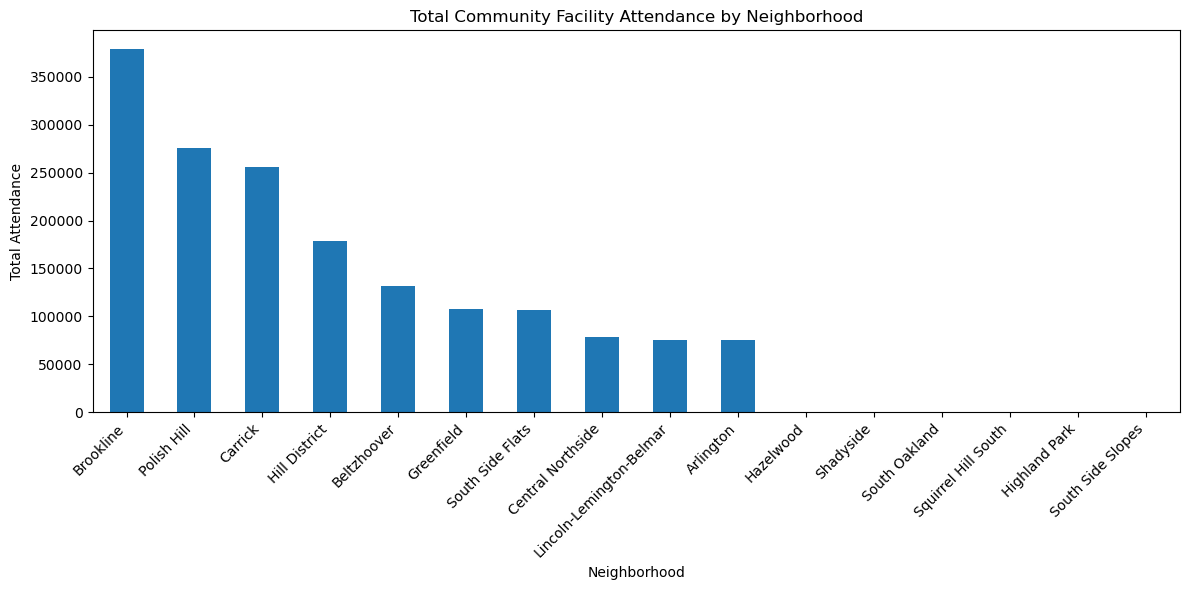

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
result.plot(kind="bar")

plt.title("Total Community Facility Attendance by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Total Attendance")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Normalized Community Attendance

After calculating the total attendance for each neighborhood, I created a normalized attendance to make the results easier to understand. The absolute attendance values are very large. Normalization changes them into a smaller scale from 0 to 1. In this scale, the neighborhood with the highest total attendance is 1.0. Every other neighborhood is scaled relative to the neighborhood with the highest total attendance.

This normalized attendance still represents community facility usage, but it makes the data more readable. A neighborhood with a score closer to 1.0 has attendance closer to the highest-attendance neighborhood, while a lower score means that the neighborhood has much less total facility usage.

In [37]:
normalized_result = result / result.max()
normalized_result = normalized_result.sort_values(ascending=False)

normalized_df = normalized_result.reset_index()
normalized_df.columns = ["Neighborhood", "Normalized_attendance"]

normalized_df

,Neighborhood,Normalized_attendance
0,Brookline,1.000000
1,Polish Hill,0.725556
2,Carrick,0.672859
3,Hill District,0.469909
4,Beltzhoover,0.347497
5,Greenfield,0.282580
6,South Side Flats,0.281866
7,Central Northside,0.207190
8,Lincoln-Lemington-Belmar,0.197520
9,Arlington,0.197346


We can now visualize the Normalized_attendance:

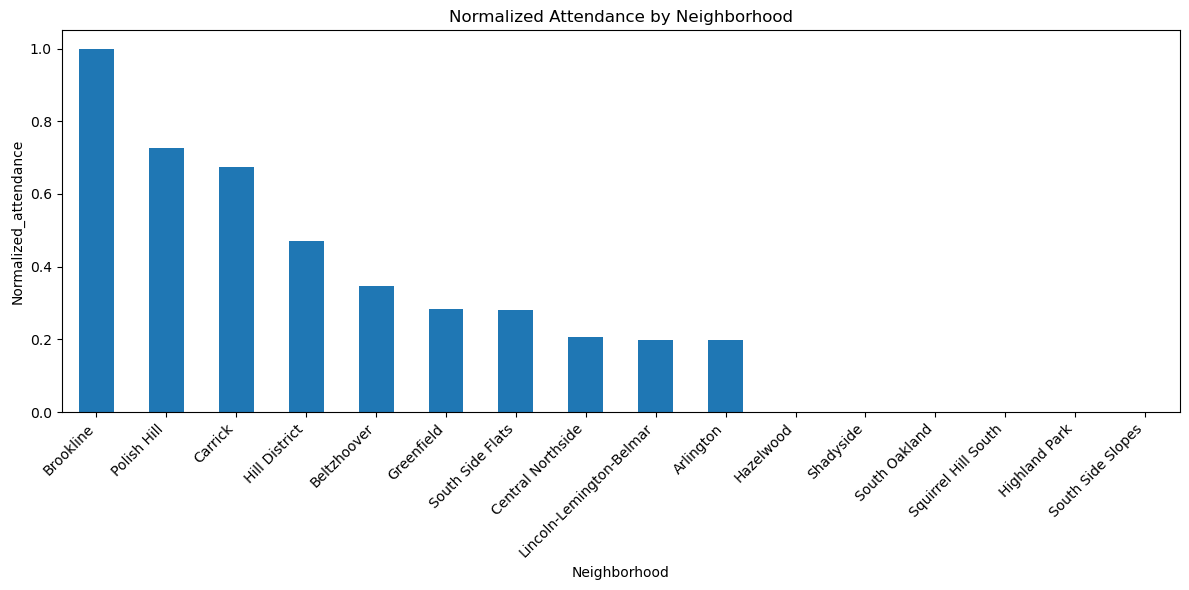

In [38]:
plt.figure(figsize=(12,6))

normalized_result.plot(kind="bar")

plt.title("Normalized Attendance by Neighborhood")
plt.xlabel("Neighborhood")

plt.ylabel("Normalized_attendance")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

# The Best Neighborhood

The results shows that Brookline has the highest normalized attendance among all neighborhoods. It is followed by Polish Hill and Carrick. They also show high level of attendance.
This indicates that Brookline has the greatest resources use among all neighborhoods. Compared to other neighborhoods, Brookline is the most active in terms of the daily total attendance. Therefore, Brookline is the best neighborhood using this metric.

# Conclusion

Actually I prefer a neighborhood depending on its traffic convenience. Based on my analysis, Brookline is identified as the best neighborhood. But in terms of the traffic convenience, Brookline may not be the best. So my personal favorite neighborhood is different from the data-driven determination of “best neighborhood”.